# Notebook for calculating APWP from the VGP compilation and using the method of Gallo et al., 2023 to propagate uncertainty through the path

## import Python libraries

In [35]:
import ast 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmagpy import ipmag, pmag
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

from matplotlib.colors import Normalize, colorConverter
from matplotlib.cm import ScalarMappable

import seaborn as sns
import scipy.stats as st

import cartopy
import cartopy.crs as ccrs

from vgptools.utils import *
from vgptools.utils_visualization import *
from vgptools.utils_classes import *
from vgptools.utils_APWPs import *

import cartopy.crs as ccrs

%matplotlib inline
%config InlineBackend.figure_formats = 'retina'

## import site-level compilation data

In [36]:
Keweenawan_track_site_data_w_MAD_conversion = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_w_MAD_conversion.csv')
# Keweenawan_track_site_data_wo_MAD_conversion = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_wo_MAD_conversion.csv')
# Keweenawan_track_site_data_w_MAD_filter = pd.read_csv('../data/pmag_compiled/Keweenawan_track_sites_w_MAD_filter.csv')

print(f"Number of sites (w MAD conversion): {len(Keweenawan_track_site_data_w_MAD_conversion)}")
# print(f"Number of sites (wo MAD conversion): {len(Keweenawan_track_site_data_wo_MAD_conversion)}")
# print(f"Number of sites (w MAD filter): {len(Keweenawan_track_site_data_w_MAD_filter)}")

Number of sites (w MAD conversion): 990


In [37]:
Keweenawan_track_site_data_w_MAD_conversion['pole_name'].unique()

<StringArray>
[                           'Osler reverse lower',
                            'Osler reverse upper',
                                   'Osler normal',
                              'Mamainse lower R1',
                              'Mamainse lower R2',
                          'Mamainse lower normal',
                          'Mamainse upper normal',
                          'Grand Portage Basalts',
 'North Shore Volcanic Group (upper NE sequence)',
 'North Shore Volcanic Group (upper SW sequence)',
                       'Schroeder Lutsen Basalts',
                         'Portage Lake Volcanics',
                               'Lake Shore Traps',
                    'Powder Mill Group Volcanics',
       'Quebec Mine Member (Michipicoten Island)',
                  'Michipicoten Island Formation',
                                         'SWLLIP',
                                 'Duluth Complex',
                           'Beaver River diabase',
                 

In [38]:
# use leave-one-out method to see if it is the CutFace, Freda, or the Nonesuch that causes the high rates near ca 1085 Ma

Keweenawan_track_site_data_w_MAD_conversion_no_Oronto = Keweenawan_track_site_data_w_MAD_conversion[(Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Freda Formation') & (Keweenawan_track_site_data_w_MAD_conversion['pole_name'] != 'Nonesuch Formation')].reset_index(drop=True)


In [39]:
Keweenawan_track_site_data_w_MAD_conversion

,pole_name,citations,location,site,lat,lon,age,age_high,age_low,age_unit,...,lithologies,geologic_types,age_model,height_type,height,height_upper,height_lower,paleolatitude,Plon,Plat
0,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(11.8 to 26.4),48.8122,272.3380,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,11.8,NaN,NaN,-54.692457,229.588330,33.098356
1,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(116.3 to 118.8),48.8062,272.3366,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,116.3,NaN,NaN,-54.393410,231.831739,30.447349
2,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(119.7 to 122.1),48.8060,272.3366,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,119.7,NaN,NaN,-52.341346,223.912252,35.321456
3,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(122.1 to 123.7),48.8058,272.3367,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,122.1,NaN,NaN,-52.630096,229.585495,29.952660
4,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(28.3 to 29.2),48.8107,272.3377,1108.0,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,28.3,NaN,NaN,-49.396782,210.954452,45.769076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,Nonesuch Formation,"Henry, 1977",Presque Isle River,33,46.6680,-89.9400,1080.0,1085.57,1075.00,Ma,...,Shale,Sediment Layer,Oronto Group,exact,1950.0,NaN,NaN,13.471886,175.379813,23.024456
986,Freda Formation,"Henry, 1977",Presque Isle River,34,46.6720,-89.9400,1070.0,1075.00,1050.00,Ma,...,Sandstone,Sediment Layer,Oronto Group,exact,2078.0,NaN,NaN,0.800156,194.743613,-12.377273
987,Freda Formation,"Henry, 1977",Presque Isle River,35,46.6740,-89.9400,1070.0,1075.00,1050.00,Ma,...,Sandstone,Sediment Layer,Oronto Group,exact,2123.0,NaN,NaN,2.756350,186.976630,-2.714175
988,Nonesuch Formation,"Henry, 1977",Silver City,40,46.8320,-89.5720,1080.0,1085.57,1075.00,Ma,...,Shale,Sediment Layer,Oronto Group,exact,2065.0,NaN,NaN,9.768497,174.426407,18.987796


In [40]:
Keweenawan_track_site_data_w_MAD_conversion_no_Oronto

,pole_name,citations,location,site,lat,lon,age,age_high,age_low,age_unit,...,lithologies,geologic_types,age_model,height_type,height,height_upper,height_lower,paleolatitude,Plon,Plat
0,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(11.8 to 26.4),48.812200,272.338000,1108.00,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,11.8,NaN,NaN,-54.692457,229.588330,33.098356
1,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(116.3 to 118.8),48.806200,272.336600,1108.00,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,116.3,NaN,NaN,-54.393410,231.831739,30.447349
2,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(119.7 to 122.1),48.806000,272.336600,1108.00,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,119.7,NaN,NaN,-52.341346,223.912252,35.321456
3,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(122.1 to 123.7),48.805800,272.336700,1108.00,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,122.1,NaN,NaN,-52.630096,229.585495,29.952660
4,Osler reverse lower,Swanson-Hysell et al. 2014,Simpson Island,SI1(28.3 to 29.2),48.810700,272.337700,1108.00,1110.00,1105.15,Ma,...,Basalt,Lava Flow,Osler Volcanic Group,exact,28.3,NaN,NaN,-49.396782,210.954452,45.769076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Cardenas Basalt,This study,Grand Canyon,CB17,36.111389,-111.855278,1082.18,1082.43,1081.93,Ma,...,Basalt,Lava Flow,NaN,NaN,NaN,NaN,NaN,30.169592,185.852989,13.467075
773,Cardenas Basalt,This study,Grand Canyon,CB18,36.111667,-111.855833,1082.18,1082.43,1081.93,Ma,...,Basalt,Lava Flow,NaN,NaN,NaN,NaN,NaN,32.899814,178.854115,30.167779
774,Cardenas Basalt,This study,Grand Canyon,CB8,36.107222,-111.848611,1082.18,1082.43,1081.93,Ma,...,Basalt,Lava Flow,NaN,NaN,NaN,NaN,NaN,21.688604,174.528874,14.663752
775,Cardenas Basalt,This study,Grand Canyon,CB9,36.107330,-111.849290,1082.18,1082.43,1081.93,Ma,...,Basalt,Lava Flow,NaN,NaN,NaN,NaN,NaN,14.470548,162.265821,19.341844


## load age models

In [41]:
Keweenawan_track_site_data_w_MAD_conversion['age_model'].unique()

<StringArray>
[         'Osler Volcanic Group',                             nan,
      'Mamainse Point Volcanics', 'North Shore Volcanic Group NE',
 'North Shore Volcanic Group SW',        'Portage Lake Volcanics',
 'Michipicoten Island Formation',                  'Oronto Group']
Length: 8, dtype: str

In [42]:
all_section_names = ['Osler Volcanic Group', 'Mamainse Point Volcanics',
       'North Shore Volcanic Group NE', 'North Shore Volcanic Group SW',
       'Portage Lake Volcanics', 'Michipicoten Island Formation', 'Oronto Group']
all_age_model_paths = ['../data/age_models_output/Osler_Volcanic_Group_posterior_ages.csv',
                       '../data/age_models_output/Mamainse_Point_Volcanic_Group_posterior_ages.csv',
                       '../data/age_models_output/NSVG_NE_posterior_ages.csv',
                       '../data/age_models_output/NSVG_SW_posterior_ages.csv',
                       '../data/age_models_output/PLV_posterior_ages.csv',
                       '../data/age_models_output/Michipicoten_posterior_ages.csv',
                       '../data/age_models_output/Oronto_Group_posterior_ages.csv']
all_age_model_posteriors = [pd.read_csv(i) for i in all_age_model_paths]

age_model_posterior_df = pd.DataFrame({'posterior_age_model': all_age_model_posteriors}, index=all_section_names)
age_model_posterior_df

,posterior_age_model
Osler Volcanic Group,height x2 x3 ...
Mamainse Point Volcanics,height x2 x3 ...
North Shore Volcanic Group NE,height x2 x3 ...
North Shore Volcanic Group SW,height x2 x3 ...
Portage Lake Volcanics,height x2 x3 ...
Michipicoten Island Formation,height x2 x3 ...
Oronto Group,height x2 x3 ...


## load f factors

In [43]:
# note that we use the same f factors for Freda and Nonesuch
all_seds_sections = ['Freda Formation', 'Nonesuch Formation', 'Cut Face Creek Sandstone']
all_seds_f_paths = ['../data/pmag_compiled/Slotznick2023/flattening_factors.csv', 
                    '../data/pmag_compiled/Slotznick2023/flattening_factors.csv', 
                    '../data/pmag_compiled/Pierce2022/flattening_factors.csv']
all_seds_f = [pd.read_csv(i, header=None) for i in all_seds_f_paths]

seds_f_df = pd.DataFrame({'f_factors': all_seds_f}, index=all_seds_sections)
seds_f_df

,f_factors
Freda Formation,0 0 0.968188 1 0.872105 2 ...
Nonesuch Formation,0 0 0.968188 1 0.872105 2 ...
Cut Face Creek Sandstone,0 0 0.994871 1 0.984513 2 ...


## construct the ultimate VGP resampling function

In [44]:
np.random.seed(2024)

n_sims = 3000

### 1. resample the Keweenawan_track_site_data_w_MAD_conversion

In [45]:
df_ultimate_RM_ensemble_w_MAD, pseudo_ultimate_sites_ensemble_w_MAD = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_w_MAD_conversion, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075, window_length=15)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 260 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 422 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:   45.8s
[Parallel(n_jobs=-1)]: Done 854 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1124 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1430 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1772 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 2150 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2564 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:  3.5min finished


In [46]:
pseudo_ultimate_sites_ensemble_w_MAD.shape

(2970000, 12)

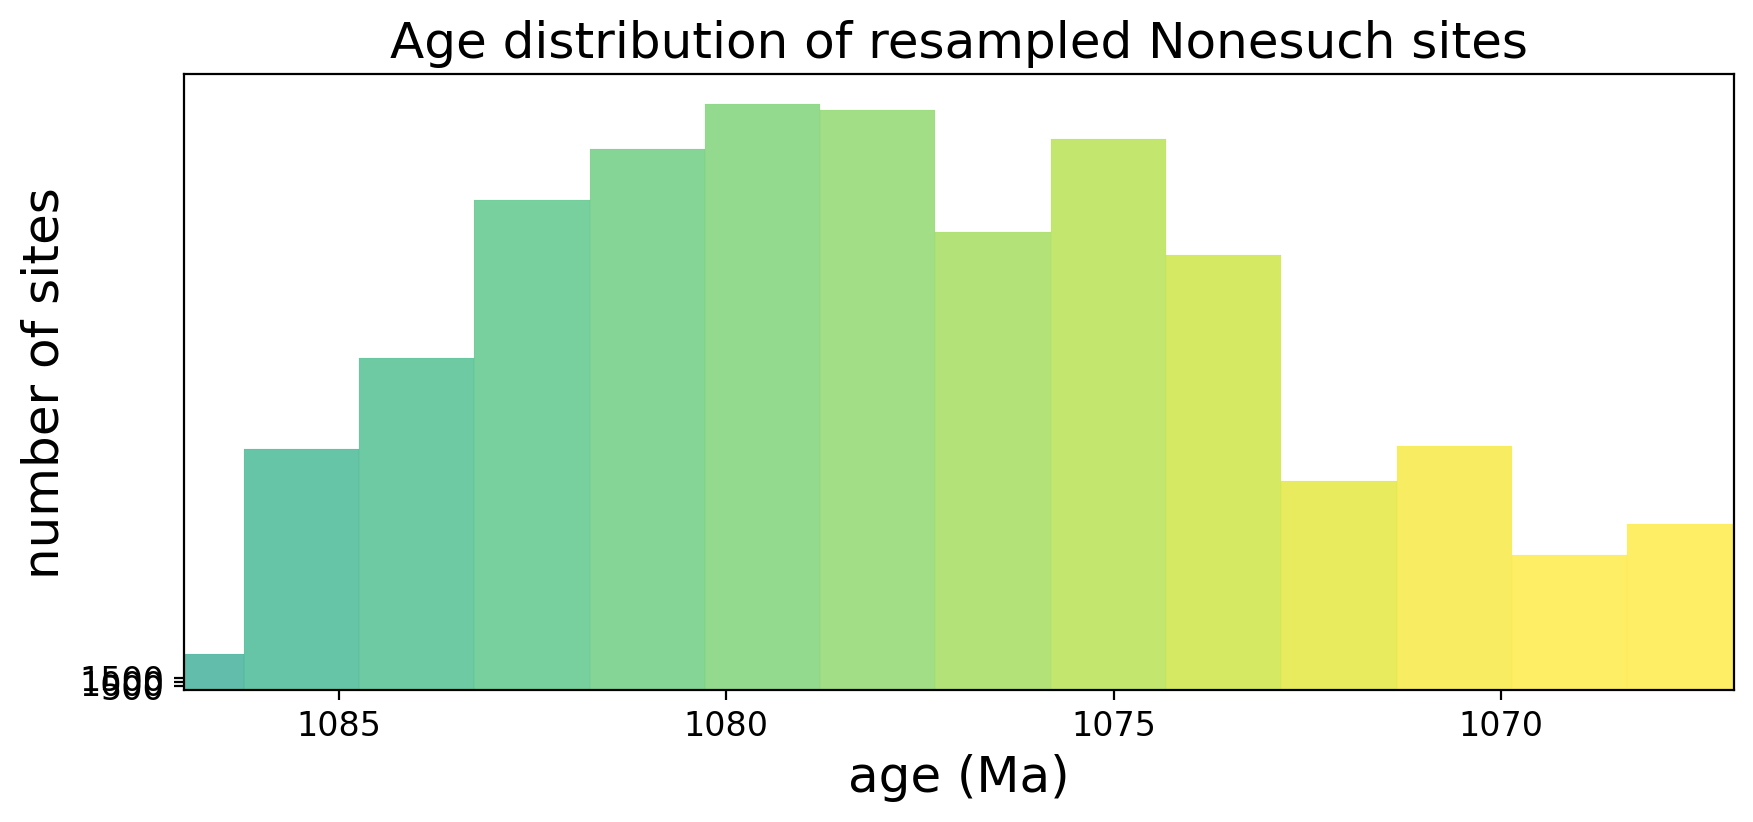

In [47]:
resampled_Oronto = pseudo_ultimate_sites_ensemble_w_MAD[(pseudo_ultimate_sites_ensemble_w_MAD['study']=='Nonesuch Formation') | (pseudo_ultimate_sites_ensemble_w_MAD['study']=='Freda Formation')]['age']

bins = 25
hist, bin_edges = np.histogram(resampled_Oronto, bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
# plt.gca().invert_xaxis()

# ax.set_yticks([])
plt.xlim(1087, 1067)
plt.xticks([1085, 1080, 1075, 1070], fontsize=12)
plt.yticks([500, 1000, 1500], fontsize=12)
ax.set_xlabel('age (Ma)', fontsize=18)
ax.set_ylabel('number of sites', fontsize=18)
plt.title('Age distribution of resampled Nonesuch sites', fontsize=18)
# plt.savefig('../figure/Nonesuch_site_age_hist.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in [1070., 1075., 1080., 1085., 1090., 1095., 1100., 1105., 1110.]:
        pole = df_ultimate_RM_ensemble_w_MAD[df_ultimate_RM_ensemble_w_MAD['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculatrio
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_w_MAD,"effective_age","plat","plon") # set principal component for each Age

# # Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_w_MAD,"effective_age", "APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age", "APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

In [ ]:
mean_plons = ensemble_PC_eff_age.PC(quantile)[0]
mean_plats = ensemble_PC_eff_age.PC(quantile)[1]
mean_thetas = ensemble_PC_eff_age.PC(quantile)[2]

# toss nan values
mean_plons = mean_plons[~np.isnan(mean_plons)]
mean_plats = mean_plats[~np.isnan(mean_plats)]
mean_thetas = mean_thetas[~np.isnan(mean_thetas)]
mean_ages = ensemble_PC_eff_age.X[~np.isnan(ensemble_PC_eff_age.PC(quantile)[0])]


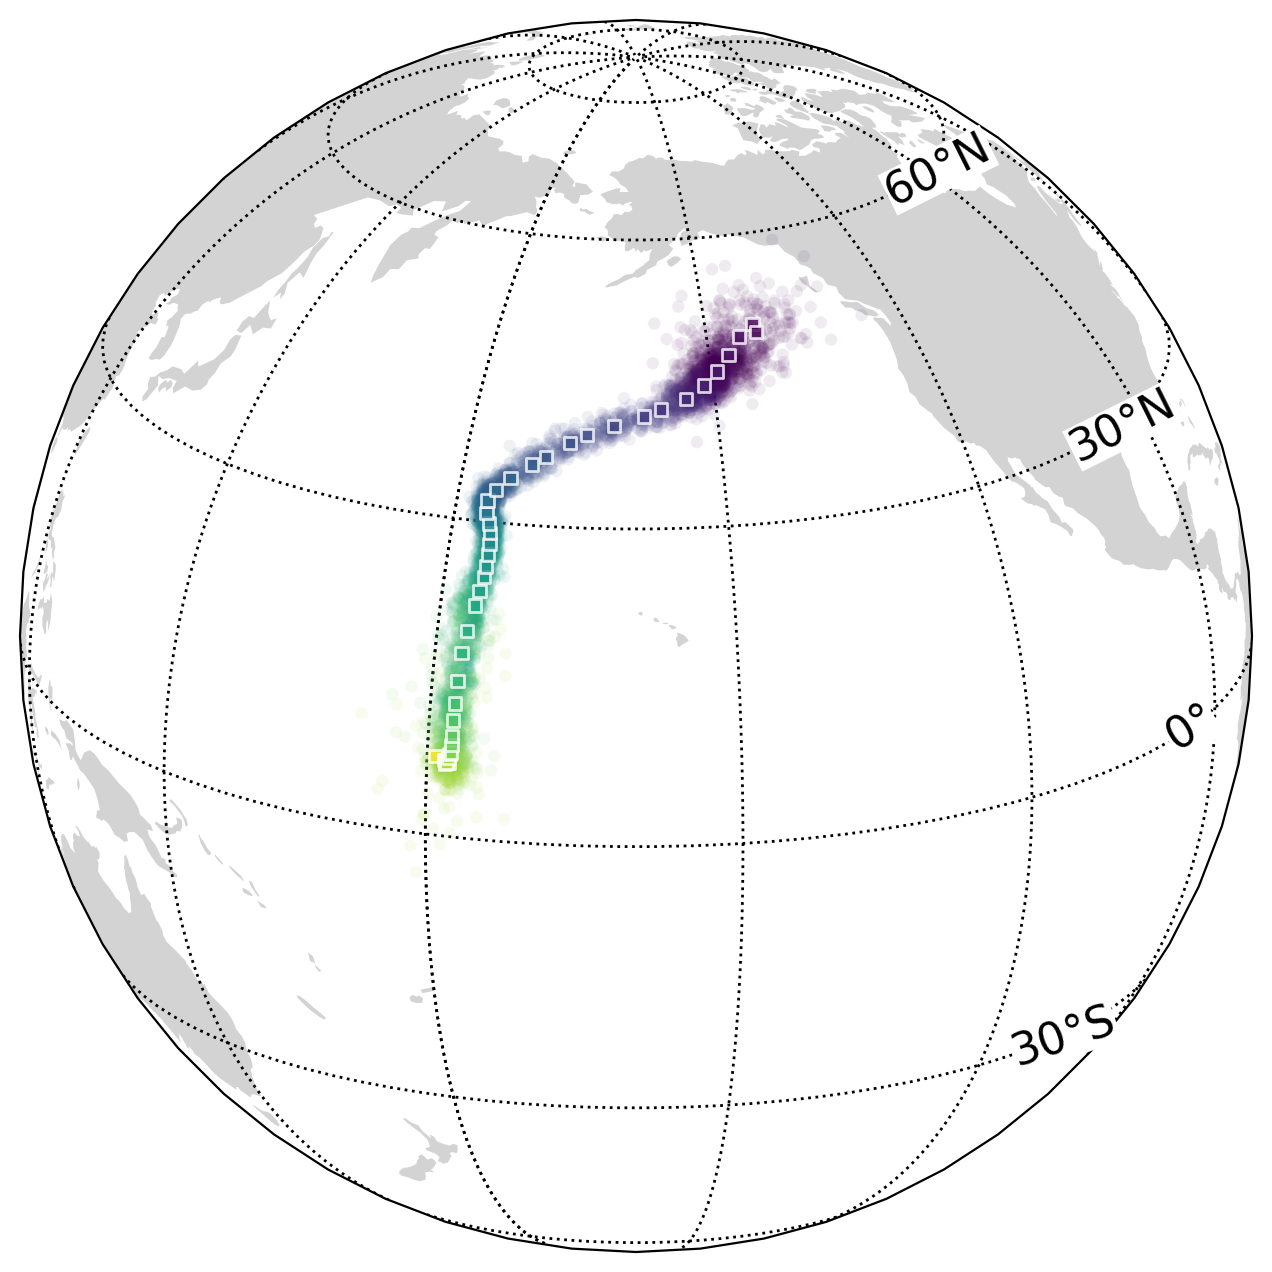

In [ ]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')

n_shown = 5000
df_ultimate_RM_ensemble_w_MAD_sampled = df_ultimate_RM_ensemble_w_MAD.sample(n=n_shown, random_state=2024).reset_index(drop=True)

ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_w_MAD_sampled['plon'], df_ultimate_RM_ensemble_w_MAD_sampled['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_w_MAD_sampled.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_w_MAD_sampled['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)

ipmag.plot_poles_colorbar(ax, mean_plons, mean_plats, 
                          np.zeros(len(mean_plons)), marker='s',
                            colorvalues=mean_ages, vmin=1070, vmax=1110,
                            colormap='viridis_r', 
                            alpha=0.8, edgecolor='white', colorbar=0)

# Add latitude labels inside the right globe boundary and rotate along latitude lines.
label_lons = [245.0, 260.0, 255.0, 255.0]
tangent_dlon = 1.5
src_crs = ccrs.PlateCarree()
for lat, label_lon in zip([-30, 0, 30, 60], label_lons):
    chosen = None
    
    x0, y0 = ax.projection.transform_point(label_lon, lat, src_crs)
    x1, y1 = ax.projection.transform_point(label_lon + tangent_dlon, lat, src_crs)
    
    chosen = (x0, y0, x1, y1)


    if chosen is None:
        continue

    x0, y0, x1, y1 = chosen
    p0 = ax.transData.transform((x0, y0))
    p1 = ax.transData.transform((x1, y1))
    angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    if lat == 0:
        lat_label = '0°'
    else:
        lat_label = f"{abs(lat)}°{'N' if lat > 0 else 'S'}"

    ax.text(
        x0,
        y0,
        lat_label,
        transform=ax.transData,
        ha='left',
        va='center',
        rotation=angle,
        rotation_mode='anchor',
        fontsize=16,
        zorder=20,
        bbox=dict(facecolor='white', edgecolor='none', alpha=1.0, pad=0.25)
    )


plt.savefig('../figure/Keweenawan_ultimate_ensemble_VGPs.png', dpi=300, bbox_inches='tight')

#### calcualte average APWP rates

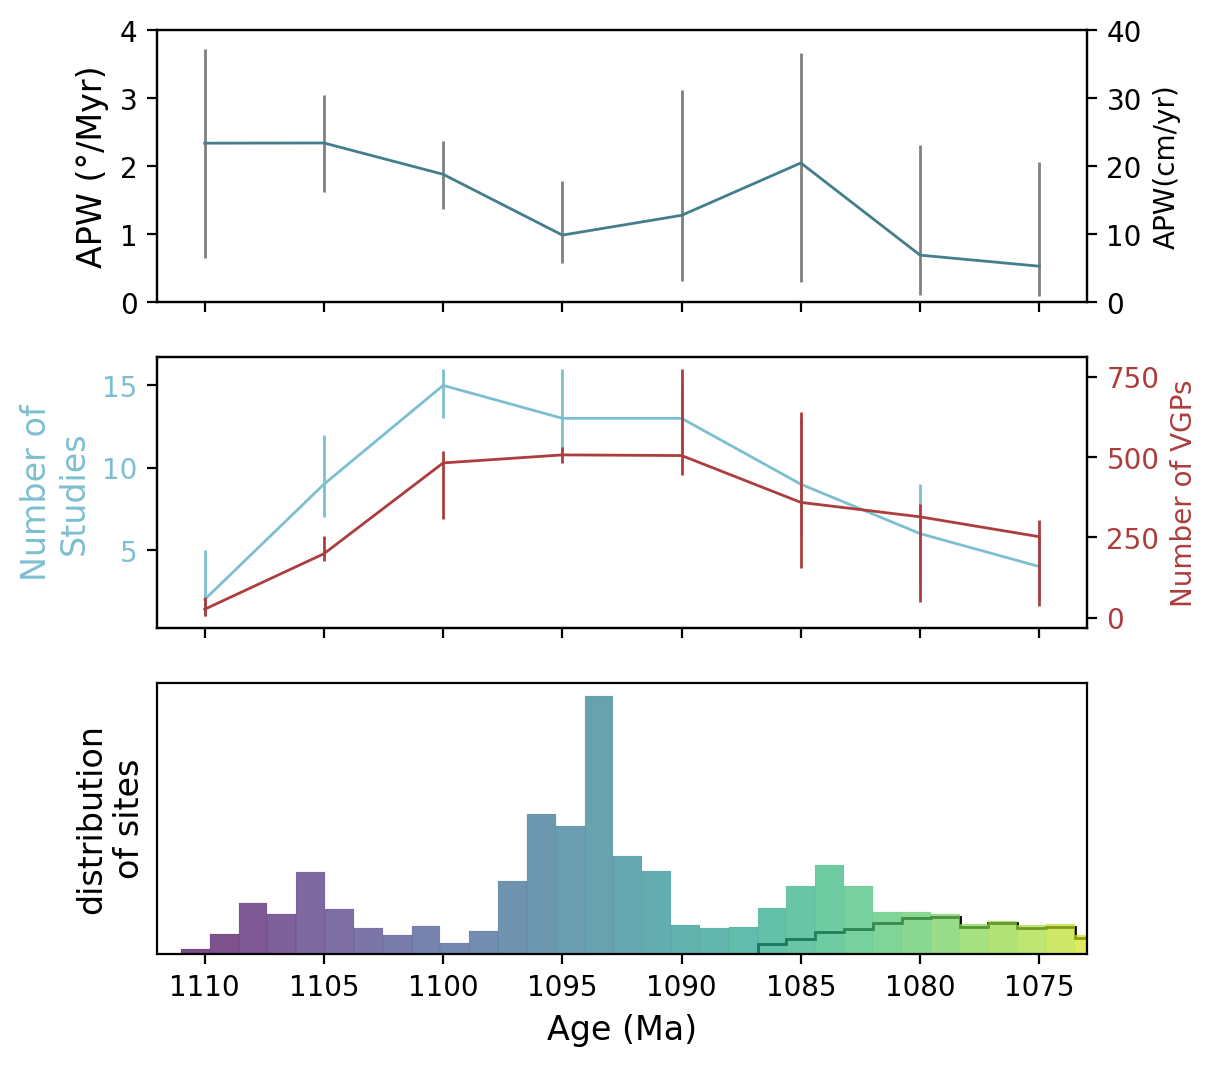

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)',  fontsize = 12)
axes[1].set_ylabel('Number of\nStudies',  fontsize = 12, color="#7DBFD2")
axes[2].set_ylabel('distribution\nof sites',  fontsize = 12)
axes[2].set_yticks([])
axes[2].set_xlabel(r'Age (Ma)',  fontsize = 12)

apw_order = np.argsort(ensemble_apw_ef_.X)
apw_x = np.asarray(ensemble_apw_ef_.X)[apw_order]
apw_y = np.asarray(ensemble_apw_ef_.q50)[apw_order]
apw_yerr = np.vstack([
    apw_y - np.asarray(ensemble_apw_ef_.q025)[apw_order],
    np.asarray(ensemble_apw_ef_.q975)[apw_order] - apw_y,
])
axes[0].errorbar(
    apw_x,
    apw_y,
    yerr=apw_yerr,
    fmt='-',
    color="#427E8C",
    ecolor="grey",
    linewidth=1,
    elinewidth=1,
    capsize=0,
    zorder=3,
    label="Ensemble Median",
)
axes[0].set_ylim(0, 4.0)
axes[0].set_yticks([0, 1, 2, 3, 4])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4], [0, 10, 20, 30, 40])
ax1.set_ylabel('APW(cm/yr)', color="k")

study_order = np.argsort(ensemble_n_studies.X)
study_x = np.asarray(ensemble_n_studies.X)[study_order][1:]
study_y = np.asarray(ensemble_n_studies.q50)[study_order][1:]
study_yerr = np.vstack([
    study_y - np.asarray(ensemble_n_studies.q025)[study_order][1:],
    np.asarray(ensemble_n_studies.q975)[study_order][1:] - study_y,
])
axes[1].errorbar(
    study_x,
    study_y,
    yerr=study_yerr,
    fmt='-',
    color="#7DBFD2",
    ecolor="#7DBFD2",
    linewidth=1,
    elinewidth=1,
    alpha=1,
    capsize=0,
    zorder=3,
)
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")

ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis
vgp_order = np.argsort(ensemble_n_vgps.X)
vgp_x = np.asarray(ensemble_n_vgps.X)[vgp_order][1:]
vgp_y = np.asarray(ensemble_n_vgps.q50)[vgp_order][1:]
vgp_yerr = np.vstack([
    vgp_y - np.asarray(ensemble_n_vgps.q025)[vgp_order][1:],
    np.asarray(ensemble_n_vgps.q975)[vgp_order][1:] - vgp_y,
])
ax2.errorbar(
    vgp_x,
    vgp_y,
    yerr=vgp_yerr,
    fmt='-',
    color="#ac3d3d",
    ecolor="#ac3d3d",
    linewidth=1,
    elinewidth=1,
    alpha=1,
    capsize=0,
    zorder=3,
)
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)

# Plot the histogram
# Define shared bins
all_data = pseudo_ultimate_sites_ensemble_w_MAD['age']
all_data_bins = np.linspace(all_data.min(), all_data.max(), 51)

# Histogram 1

hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD['age'], bins=all_data_bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

# Plot the histogram
for i in range(len(all_data_bins) - 1):
    axes[2].bar(bin_edges[i], hist[i], width=bin_edges[i+1] - bin_edges[i],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.3), lw=0.05)
    


# # Histogram 1
# pseudo_ultimate_sites_ensemble_w_MAD['age'].hist(
#     bins=all_data_bins,
#     color='lightgrey',
#     edgecolor=None,
#     ax=axes[2],
#     # histtype='step',
#     zorder=0
# )

# Histogram 2
resampled_Oronto = pseudo_ultimate_sites_ensemble_w_MAD[
    pseudo_ultimate_sites_ensemble_w_MAD['study']=='Nonesuch Formation'
]['age']

hist, bin_edges = np.histogram(resampled_Oronto, bins=all_data_bins)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

resampled_Oronto.hist(
    bins=all_data_bins,
    color='skyblue',
    edgecolor=None,
    ax=axes[2],
    histtype='step',
    zorder=0
)


# for i in range(len(bin_edges) - 1):
#     axes[2].bar(
#         bin_edges[i],
#         hist[i],
#         width=bin_edges[i+1] - bin_edges[i],
#         color=cmap(norm(bin_centers[i])),
#         align='edge',
#         alpha=0.3,
#         edgecolor='none'
#     )
axes[2].grid(False)


axes[0].set_xlim(1112, 1073)
axes[1].set_xlim(1112, 1073)
axes[2].set_xlim(1112, 1073)

plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats.pdf', bbox_inches='tight')

In [ ]:
# Detect the onset of longitude slowdown with a segmented linear fit.
# We unwrap longitude first so the breakpoint search is not distorted by angular wraparound.
valid = np.isfinite(ensemble_PC_eff_age.X) & np.isfinite(ensemble_PC_eff_age.PC(quantile)[0])
break_ages = np.asarray(ensemble_PC_eff_age.X[valid], dtype=float)
break_lon_deg = np.degrees(
    np.unwrap(np.radians(ensemble_PC_eff_age.PC(quantile)[0][valid]), discont=np.radians(180.0))
)

single_fit = np.polyfit(break_ages, break_lon_deg, 1)
single_pred = np.polyval(single_fit, break_ages)
single_rss = np.sum((break_lon_deg - single_pred) ** 2)

breakpoint_rows = []
for split_idx in range(3, len(break_ages) - 3):
    younger_ages = break_ages[: split_idx + 1]
    older_ages = break_ages[split_idx:]
    younger_lon = break_lon_deg[: split_idx + 1]
    older_lon = break_lon_deg[split_idx:]

    younger_fit = np.polyfit(younger_ages, younger_lon, 1)
    older_fit = np.polyfit(older_ages, older_lon, 1)

    younger_pred = np.polyval(younger_fit, younger_ages)
    older_pred = np.polyval(older_fit, older_ages)
    segmented_rss = np.sum((younger_lon - younger_pred) ** 2) + np.sum((older_lon - older_pred) ** 2)

    rss_gain = single_rss - segmented_rss
    slope_jump = np.abs(older_fit[0]) - np.abs(younger_fit[0])
    breakpoint_score = rss_gain * slope_jump

    breakpoint_rows.append(
        {
            'age': break_ages[split_idx],
            'younger_slope': younger_fit[0],
            'older_slope': older_fit[0],
            'rss_gain': rss_gain,
            'slope_jump': slope_jump,
            'score': breakpoint_score,
        }
    )

elbow_scores = pd.DataFrame(breakpoint_rows)
best_breakpoint_score = elbow_scores['score'].max()
near_optimal_breakpoints = elbow_scores[elbow_scores['score'] >= 0.97 * best_breakpoint_score].sort_values('age')

# The best-fit breakpoint marks the center of the transition. We report the earliest
# near-optimal breakpoint as the slowdown onset, which is more stable for low-resample runs.
elbow_age = near_optimal_breakpoints['age'].iloc[0]
age_spacing = np.median(np.diff(np.sort(break_ages)))
elbow_uncertainty = max(
    0.5 * (near_optimal_breakpoints['age'].iloc[-1] - near_optimal_breakpoints['age'].iloc[0]),
    age_spacing / 2,
)

print(
    f"Longitude slowdown onset: {elbow_age:.1f} ± {elbow_uncertainty:.1f} Ma "
    f"(near-optimal breakpoint range {near_optimal_breakpoints['age'].min():.1f}-{near_optimal_breakpoints['age'].max():.1f} Ma)"
)

Longitude slowdown onset: 1096.0 ± 1.0 Ma (near-optimal breakpoint range 1096.0-1098.0 Ma)


### Longitude Slowdown Detection Algorithm

The onset of the longitude slowdown is detected using segmented linear regression with breakpoint scoring. The method:
(1) unwraps the angular longitude data to avoid wraparound distortion, (2) evaluates each possible age as a breakpoint by fitting separate linear trends before and after the split, (3) scores each breakpoint as the product of RSS improvement (fit gain from two-segment model) and slope magnitude change (transition in rate), and (4) selects the earliest age within the "near-optimal" range (≥97% of maximum score) as the slowdown onset. This approach robustly identifies the phase transition in APW rate while remaining stable across low-resample ensemble runs.

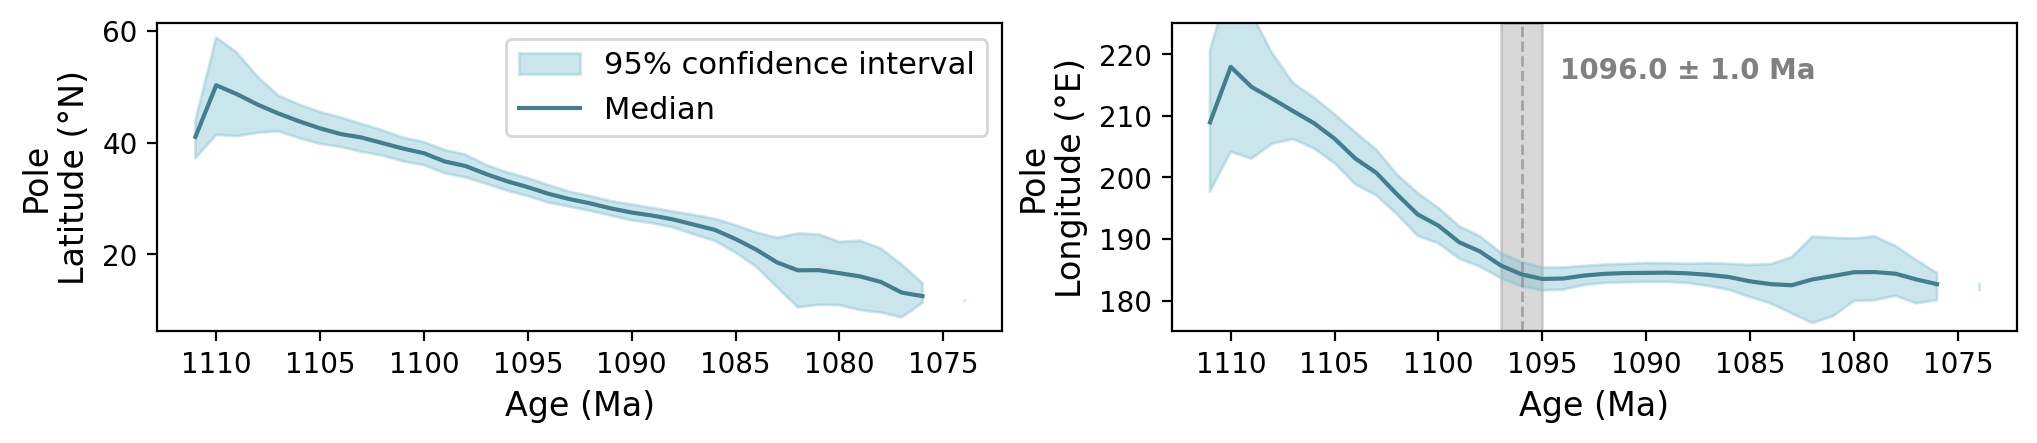

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,2), sharex=True)

# Set Axis Labels
axes[0].set_ylabel('Pole\nLatitude (°N)',  fontsize = 12)
axes[0].set_xlabel('Age (Ma)',  fontsize = 12)

axes[1].set_ylabel('Pole\nLongitude (°E)',  fontsize = 12)
axes[1].set_xlabel('Age (Ma)',  fontsize = 12)

# LATITUDES 
# for run, df_run in df_ultimate_RM_ensemble_w_MAD.groupby('run'):
#     axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)

# axes[0].plot(df_run.effective_age.tolist(), df_run.plat.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[0].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"{quantile}% confidence interval")
# axes[0].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#314B54", s = 15,  label = 'Principal component of the age ensemble')  
axes[0].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[1],color="#427E8C", label='Median')  
axes[0].legend(loc='upper right', fontsize=11)

# LONGITUDES     
# for run, df_run in df_ultimate_RM_ensemble_w_MAD.groupby('run'):
#     axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, alpha=0.2)
# axes[1].plot(df_run.effective_age.tolist(), df_run.plon.tolist(), color="#4F4F4F", zorder =0, linewidth=0.2, label = 'Moving Average realization')
axes[1].fill_between(ensemble_PC_eff_age.X, ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], 
                     ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], 
                     color= "#7DBFD2", alpha=.40, zorder =1, label=f"Empirical {quantile}% confidence interval")
# axes[1].scatter(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#314B54", s = 15,  label = 'Principal component of the age ensemble')
axes[1].plot(ensemble_PC_eff_age.X, ensemble_PC_eff_age.PC(quantile)[0]%360,color="#427E8C")  

# Add grey vertical band showing the onset of longitude slowdown and the near-optimal age range.
axes[1].axvspan(elbow_age - elbow_uncertainty, elbow_age + elbow_uncertainty, color='grey', alpha=0.3, zorder=0, label='Longitude slowdown onset')
axes[1].axvline(elbow_age, color='grey', linestyle='--', linewidth=1, alpha=0.6, zorder=1)

# Add label for the elbow point and uncertainty
axes[1].text(elbow_age-8, 215, f'{elbow_age:.1f} ± {elbow_uncertainty:.1f} Ma', 
             fontsize=10, ha='center', va='bottom', color='grey', fontweight='bold')

# axes[0].set_ylim(3, 55)

axes[1].set_ylim(175, 225)

plt.gca().invert_xaxis()
plt.savefig('../figure/Keweenawan_ultimate_ensemble_APW_components.pdf', bbox_inches='tight')
plt.show()


### APWP

In [20]:
apwp_columns = {
    'Age': np.asarray(ensemble_PC_eff_age.X, dtype=float),
    'Plat': np.asarray(ensemble_PC_eff_age.PC(quantile)[1], dtype=float),
    'Plon': np.asarray(ensemble_PC_eff_age.PC(quantile)[0], dtype=float),
    'Theta 95': np.asarray(ensemble_PC_eff_age.PC(quantile)[2], dtype=float),
    'max lat': np.asarray(ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[3], dtype=float),
    'min lat': np.asarray(ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[2], dtype=float),
    'max lon': np.asarray(ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[1], dtype=float),
    'min lon': np.asarray(ensemble_PC_eff_age.Lat_Lon_bounds(quantile)[0], dtype=float),
}

max_len = max(len(values) for values in apwp_columns.values())
def pad_with_nan(values, target_len):
    padded = np.full(target_len, np.nan)
    padded[:len(values)] = values
    return padded

apwp_eff = {name: pad_with_nan(values, max_len) for name, values in apwp_columns.items()}
common_valid = np.all(
    np.isfinite(np.column_stack([apwp_eff[name] for name in apwp_eff])),
    axis=1,
)

df_apwp_eff = pd.DataFrame({name: values[common_valid] for name, values in apwp_eff.items()})
df_apwp_eff.to_csv('./apwp_output/Keweenawan_track_VGP_APWP.csv', index=False)
df_apwp_eff

,Age,Plat,Plon,Theta 95,max lat,min lat,max lon,min lon
0,1069.0,7.116930,182.153041,1.889376,5.496569,8.530505,180.647716,184.035848
1,1070.0,7.688653,180.807834,7.390134,4.514503,11.790019,174.195175,185.014509
2,1071.0,7.385891,181.710436,4.593277,4.182445,10.472158,178.544126,184.829641
3,1072.0,7.293651,181.825528,4.133730,4.593543,11.305360,178.911030,185.868522
4,1073.0,7.410147,181.882000,5.083533,2.385705,12.116155,177.691596,184.904324
5,1074.0,7.057627,181.809775,6.873878,0.399783,12.639852,176.538079,185.245575
6,1075.0,7.179159,181.950693,5.366016,2.019148,12.435002,177.702601,185.922948
7,1076.0,7.612486,182.114466,5.938472,2.007136,13.350089,176.736041,186.898408
8,1077.0,8.013224,182.190204,6.069228,2.034208,14.015222,176.642397,186.645220
9,1078.0,8.161928,182.336606,6.413522,1.988972,14.391653,177.830930,187.707190


### 2. resample the Keweenawan_track_site_data_w_MAD_conversion_no_Oronto

In [21]:
df_ultimate_RM_ensemble_w_MAD_no_Oronto, pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto = ultimate_ensemble_RMs_parallel(Keweenawan_track_site_data_w_MAD_conversion_no_Oronto, age_model_posterior_df, seds_f_df, n_sims = n_sims, min_age=1075, window_length=15)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 260 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 422 tasks      | elapsed:   22.0s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:   32.7s
[Parallel(n_jobs=-1)]: Done 854 tasks      | elapsed:   45.3s
[Parallel(n_jobs=-1)]: Done 1124 tasks      | elapsed:   59.9s
[Parallel(n_jobs=-1)]: Done 1430 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 1772 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 2150 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 2564 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:  2.7min finished


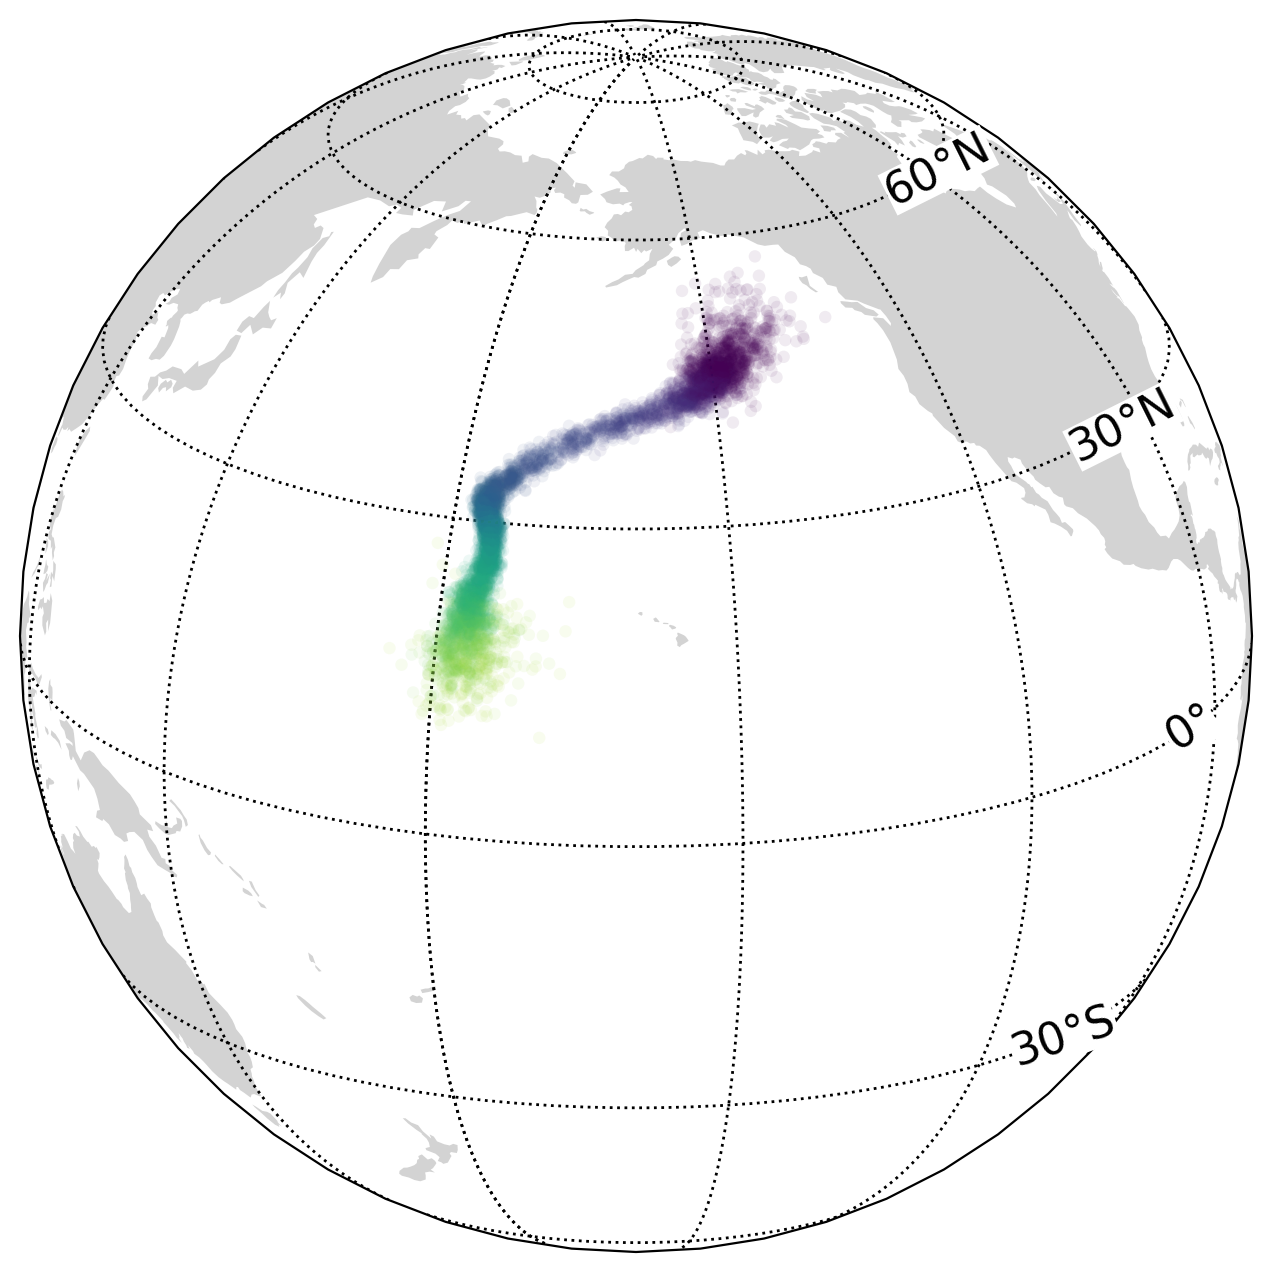

In [22]:
ax = ipmag.make_orthographic_map(200, 20, land_edge_color='none', land_color='lightgrey')

n_shown = 5000
df_ultimate_RM_ensemble_w_MAD_no_Oronto_sampled = df_ultimate_RM_ensemble_w_MAD_no_Oronto.sample(n=n_shown, random_state=2024).reset_index(drop=True)

ipmag.plot_poles_colorbar(ax, df_ultimate_RM_ensemble_w_MAD_no_Oronto_sampled['plon'], df_ultimate_RM_ensemble_w_MAD_no_Oronto_sampled['plat'], 
                          np.zeros(df_ultimate_RM_ensemble_w_MAD_no_Oronto_sampled.shape[0]), marker='o', 
                          colorvalues=df_ultimate_RM_ensemble_w_MAD_no_Oronto_sampled['age'], vmin=1070, vmax=1110, 
                          colormap='viridis_r',
                          alpha=0.08, edgecolor='none', colorbar=0)


# Add latitude labels inside the right globe boundary and rotate along latitude lines.
label_lons = [245.0, 260.0, 255.0, 255.0]
tangent_dlon = 1.5
src_crs = ccrs.PlateCarree()
for lat, label_lon in zip([-30, 0, 30, 60], label_lons):
    chosen = None
    
    x0, y0 = ax.projection.transform_point(label_lon, lat, src_crs)
    x1, y1 = ax.projection.transform_point(label_lon + tangent_dlon, lat, src_crs)
    
    chosen = (x0, y0, x1, y1)


    if chosen is None:
        continue

    x0, y0, x1, y1 = chosen
    p0 = ax.transData.transform((x0, y0))
    p1 = ax.transData.transform((x1, y1))
    angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    if lat == 0:
        lat_label = '0°'
    else:
        lat_label = f"{abs(lat)}°{'N' if lat > 0 else 'S'}"

    ax.text(
        x0,
        y0,
        lat_label,
        transform=ax.transData,
        ha='left',
        va='center',
        rotation=angle,
        rotation_mode='anchor',
        fontsize=16,
        zorder=20,
        bbox=dict(facecolor='white', edgecolor='none', alpha=1.0, pad=0.25)
    )

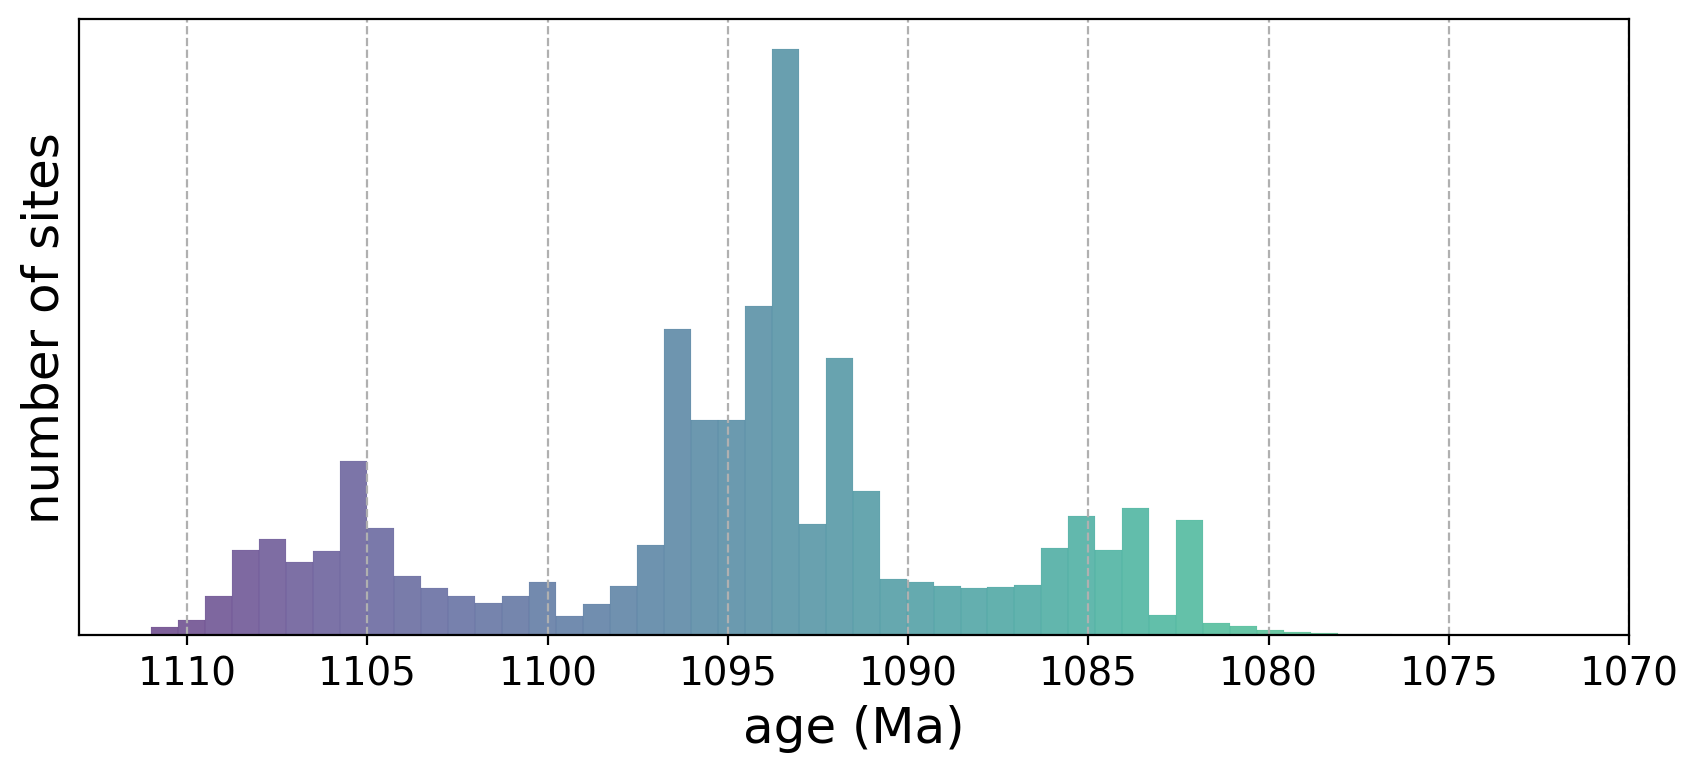

In [23]:
bins = 50
hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto['age'], bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1060, vmax=1115)
cmap = plt.cm.viridis_r

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bins):
    ax.bar(bin_edges[i], hist[i], width=bin_edges[1]-bin_edges[0],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
plt.gca().invert_xaxis()
plt.grid(True, ls='--')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.set_yticks([])
plt.xlim(1113, 1070)
plt.xticks(fontsize=14)
ax.set_xlabel('age (Ma)', fontsize=18)
ax.set_ylabel('number of sites', fontsize=18)
# plt.savefig('../figure/Keweenawan_ultimate_ensemble_site_age_hist_no_Oronto.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [24]:
ultimate_ensemble_rates = pd.DataFrame()
for j in range(n_sims):
    df = pd.DataFrame()
    for i in [1080., 1085., 1090., 1095., 1100., 1105., 1110.]:
        pole = df_ultimate_RM_ensemble_w_MAD_no_Oronto[df_ultimate_RM_ensemble_w_MAD_no_Oronto['effective_age'] == i].sample(n=1)
        df = pd.concat([df, pole], ignore_index=True)
    # The following block calculates rate of polar wander (degrees per million years) 
    df['run'] = j
    df['PPcartesian'] = df.apply(lambda row: spherical2cartesian([np.radians(row['plat']),np.radians(row['plon'])]), axis = 1)
    df['PP_prev'] = df['PPcartesian'].shift(periods = 1)
    df['PP_next'] =  df['PPcartesian'].shift(periods = -1)
    df['GCD'] = df.apply(lambda row: np.degrees(GCD_cartesian(row['PP_prev'], row['PPcartesian'])), axis = 1)
    df['APW_rate'] = df['GCD']/df['effective_age'].diff()
    ultimate_ensemble_rates = pd.concat([ultimate_ensemble_rates, df], ignore_index=True)

# Set the level confidence at which we want to work 
quantile = 95

# Since the Latitude and Longitude covaries, we need to calculate the Principal component for each timre-dependant point Cloud 
# the class PC() has also methods to aid in the calculation
ensemble_PC_eff_age = PC(df_ultimate_RM_ensemble_w_MAD_no_Oronto,"effective_age","plat","plon") # set principal component for each Age

# Ensemble's parameters (e.g. Apparent polar wander rate, age difference)
ensemble_apw_eff = quantiles(df_ultimate_RM_ensemble_w_MAD_no_Oronto,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes
ensemble_apw_ef_ = quantiles(ultimate_ensemble_rates,"effective_age","APW_rate") # set quantiles of latitude groupedby age for visualization purposes

ensemble_n_studies = quantiles(ultimate_ensemble_rates,"effective_age","n_studies")
ensemble_n_vgps = quantiles(ultimate_ensemble_rates,"effective_age","N")

#### calcualte average APWP rates

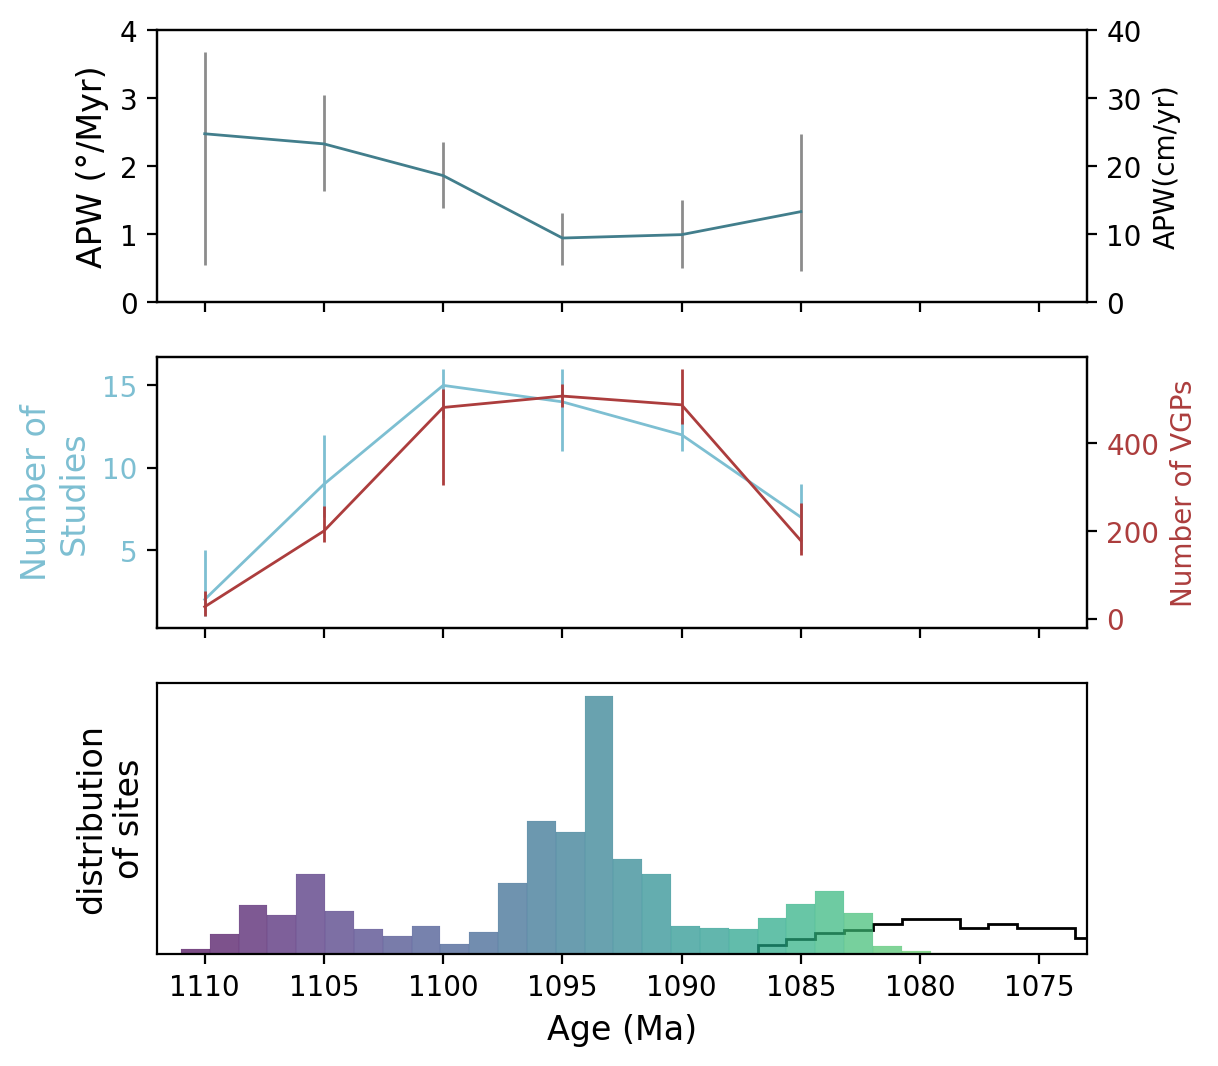

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# Set Axis Labels
axes[0].set_ylabel(r'APW (°/Myr)',  fontsize = 12)
axes[1].set_ylabel('Number of\nStudies',  fontsize = 12, color="#7DBFD2")
axes[2].set_ylabel('distribution\nof sites',  fontsize = 12)
axes[2].set_yticks([])
axes[2].set_xlabel(r'Age (Ma)',  fontsize = 12)

apw_x = np.sort(ensemble_apw_ef_.X)
apw_y = ensemble_apw_ef_.q50[np.argsort(ensemble_apw_ef_.X)]
apw_lower = apw_y - ensemble_apw_ef_.q025[np.argsort(ensemble_apw_ef_.X)]
apw_upper = ensemble_apw_ef_.q975[np.argsort(ensemble_apw_ef_.X)] - apw_y

axes[0].plot(apw_x, apw_y, color="#427E8C", zorder=3, linewidth=1, label="Ensemble Median")
axes[0].errorbar(
    apw_x,
    apw_y,
    yerr=[apw_lower, apw_upper],
    fmt='none',
    ecolor="grey",
    elinewidth=1,
    alpha=0.9,
    zorder=2,
)
axes[0].set_ylim(0, 4.0)
axes[0].set_yticks([0, 1, 2, 3, 4])
ax1 = axes[0].twinx()
ax1.set_yticks([0, 1, 2, 3, 4], [0, 10, 20, 30, 40])
ax1.set_ylabel('APW(cm/yr)', color="k")

study_x = np.sort(ensemble_n_studies.X)[1:]
study_order = np.argsort(ensemble_n_studies.X)[1:]
study_y = ensemble_n_studies.q50[study_order]
study_lower = study_y - ensemble_n_studies.q025[study_order]
study_upper = ensemble_n_studies.q975[study_order] - study_y

axes[1].plot(study_x, study_y, color="#7DBFD2", zorder=3, linewidth=1)
axes[1].errorbar(
    study_x,
    study_y,
    yerr=[study_lower, study_upper],
    fmt='none',
    ecolor="#7DBFD2",
    elinewidth=1,
    alpha=1,
    zorder=2,
)
axes[1].tick_params(axis='y', labelcolor="#7DBFD2")

ax2 = axes[1].twinx()  # instantiate a second axes that shares the same x-axis

vgp_x = np.sort(ensemble_n_vgps.X[1:])
vgp_order = np.argsort(ensemble_n_vgps.X)[1:]
vgp_y = ensemble_n_vgps.q50[vgp_order]
vgp_lower = vgp_y - ensemble_n_vgps.q025[vgp_order]
vgp_upper = ensemble_n_vgps.q975[vgp_order] - vgp_y

ax2.plot(vgp_x, vgp_y, color="#ac3d3d", zorder=3, linewidth=1)
ax2.errorbar(
    vgp_x,
    vgp_y,
    yerr=[vgp_lower, vgp_upper],
    fmt='none',
    ecolor="#ac3d3d",
    elinewidth=1,
    alpha=1,
    zorder=2,
)
ax2.set_ylabel('Number of VGPs', color="#ac3d3d")
ax2.tick_params(axis='y', labelcolor="#ac3d3d")
ax2.grid(False)

# Histogram 1

hist, bin_edges = np.histogram(pseudo_ultimate_sites_ensemble_w_MAD_no_Oronto['age'], bins=all_data_bins)
# Compute bin centers for coloring
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# Create a colormap based on the x-axis values (bin centers)
norm = Normalize(vmin=1070, vmax=1110)
cmap = plt.cm.viridis_r

# Plot the histogram
for i in range(len(all_data_bins) - 1):
    axes[2].bar(bin_edges[i], hist[i], width=bin_edges[i+1] - bin_edges[i],
           color=cmap(norm(bin_centers[i])), align='edge', alpha=0.7, edgecolor=colorConverter.to_rgba(cmap(norm(bin_centers[i])), alpha=.0), lw=0.05)
    
resampled_Oronto.hist(
    bins=all_data_bins,
    color='skyblue',
    edgecolor=None,
    ax=axes[2],
    histtype='step',
    zorder=0
)
axes[2].grid(False)

axes[0].set_xlim(1112, 1073)
axes[1].set_xlim(1112, 1073)
axes[2].set_xlim(1112, 1073)

plt.savefig('../figure/Keweenawan_ultimate_ensemble_stats_no_Oronto.pdf', bbox_inches='tight')

## plot NSVG age model

In [26]:
NSVG_age_model = pd.read_csv('../data/age_models_output/NSVG_SW_posterior_ages.csv', index_col=0)
NSVG_age_model

,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,...,x992,x993,x994,x995,x996,x997,x998,x999,x1000,x1001
height,,,,,,,,,,,,,,,,,,,,,
370.0,1098.575447,1098.658193,1098.218258,1098.368391,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1098.220263,1098.505741,1098.740941,1097.422663,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345
380.0,1098.575447,1098.658193,1098.218258,1098.368391,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1098.220263,1098.505741,1098.740941,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345
390.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1098.220263,1098.505741,1098.740941,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345
400.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1098.220263,1098.505741,1098.740941,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345
410.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1098.220263,1098.505741,1098.740941,1097.272424,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8600.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.133481,1092.933252,1092.999678,1092.784661,1091.788645,1092.927193,...,1092.886802,1093.480302,1093.420336,1092.041068,1092.766933,1092.583549,1092.102746,1093.337427,1093.543169,1093.797465
8610.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.039034,1092.933252,1092.999678,1092.784661,1091.779635,1092.927193,...,1092.886802,1093.480302,1093.420336,1092.041068,1092.766933,1092.583549,1092.102746,1093.337427,1093.543169,1093.797465
8620.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.039034,1092.933252,1092.999678,1092.784661,1091.660116,1092.927193,...,1092.867981,1093.480302,1093.420336,1092.041068,1092.766933,1092.583549,1091.811421,1093.337427,1093.543169,1093.797465


In [27]:
NSVG_SW_Name = ("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion") # Et cetera
NSVG_SW_Age           = [ 1099, 1096.75, 1096.18, 1093.94, 1091.61] # Measured ages
NSVG_SW_Age_sigma     = [ 1/2,   0.28/2,  0.32/2,  0.28/2,  0.14/2] # Measured 1-σ uncertainties
NSVG_SW_Height        = [ 370,     2000,  6215,      7980,  8645] # Depths below surface should be negative
NSVG_SW_Age_Sidedness = [-1, 0, 0, 0, 1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided


In [28]:

# now make a Julia type plot for the age model plot for this example section
# stats are by rows
NSVG_age_model['Age'] = NSVG_age_model.apply(lambda row: np.quantile(row.values, 0.5), axis=1)
NSVG_age_model['Age_025CI'] = NSVG_age_model.apply(lambda row: np.quantile(row.values, 0.025), axis=1)
NSVG_age_model['Age_975CI'] = NSVG_age_model.apply(lambda row: np.quantile(row.values, 0.975), axis=1)
NSVG_age_model

,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,...,x995,x996,x997,x998,x999,x1000,x1001,Age,Age_025CI,Age_975CI
height,,,,,,,,,,,,,,,,,,,,,
370.0,1098.575447,1098.658193,1098.218258,1098.368391,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1097.422663,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345,1098.406594,1097.368353,1099.244846
380.0,1098.575447,1098.658193,1098.218258,1098.368391,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345,1098.400536,1097.357978,1099.244846
390.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345,1098.392498,1097.357978,1099.230976
400.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1097.311386,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345,1098.387069,1097.311613,1099.229946
410.0,1098.575447,1098.658193,1098.218258,1097.885916,1098.432056,1098.240342,1098.580182,1098.796973,1098.927261,1099.011115,...,1097.272424,1098.222630,1098.605367,1098.323593,1098.066792,1098.665915,1098.913345,1098.381152,1097.307248,1099.224236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8600.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.133481,1092.933252,1092.999678,1092.784661,1091.788645,1092.927193,...,1092.041068,1092.766933,1092.583549,1092.102746,1093.337427,1093.543169,1093.797465,1092.961785,1091.963620,1093.832490
8610.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.039034,1092.933252,1092.999678,1092.784661,1091.779635,1092.927193,...,1092.041068,1092.766933,1092.583549,1092.102746,1093.337427,1093.543169,1093.797465,1092.942958,1091.955709,1093.827673
8620.0,1093.593714,1092.892987,1092.995186,1092.477964,1093.039034,1092.933252,1092.999678,1092.784661,1091.660116,1092.927193,...,1092.041068,1092.766933,1092.583549,1091.811421,1093.337427,1093.543169,1093.797465,1092.935168,1091.932503,1093.816219


In [29]:
def plot_age_model(
    age,
    age_sigma,
    age_sidedness,
    height,
    age_model,
    age_unit="Ma",
    height_unit="m",
    output_path=None,
    save_figure=False,
    model_label="model",
):
    """
    Plot an age-depth model from plain setup arrays and an age model DataFrame.

    Parameters
    ----------
    age, age_sigma, age_sidedness, height : array-like
        Setup inputs for geochronologic constraints.
    age_model : pandas.DataFrame or dict-like
        Must include Age, Height, Age_025CI, Age_975CI.
    age_unit : str, optional
        Label for age axis.
    height_unit : str, optional
        Label for height axis.
    output_path : str or None, optional
        Prefix path for saving the figure when save_figure=True.
    save_figure : bool, optional
        If True, save to output_path + 'AgeDepthModel.pdf'.
    model_label : str, optional
        Legend label for modeled age-depth envelope.
    """

    setup_age = np.asarray(age)
    setup_age_sigma = np.asarray(age_sigma)
    setup_age_sidedness = np.asarray(age_sidedness)
    setup_height = np.asarray(height)

    mdl_age = np.asarray(age_model["Age"])
    mdl_height = np.asarray(age_model.index)
    mdl_age_025 = np.asarray(age_model["Age_025CI"])
    mdl_age_975 = np.asarray(age_model["Age_975CI"])

    plt.figure(figsize=(2, 10))

    # --- Model confidence interval (shaded) ---
    x_ci = np.concatenate([mdl_age_025, mdl_age_975[::-1]])
    y_ci = np.concatenate([mdl_height, mdl_height[::-1]])
    plt.fill(x_ci, y_ci, color='grey', alpha=0.6, label=model_label)

    # --- Model center line ---
    plt.plot(mdl_age, mdl_height, color='grey', linewidth=1)

    # --- Two-sided constraints ---
    t = setup_age_sidedness == 0
    if np.any(t):
        plt.errorbar(
            setup_age[t],
            setup_height[t],
            xerr=2 * setup_age_sigma[t],
            fmt='o',
            color='black',
            label="two-sided age"
        )

    # --- Minimum ages (left error only) ---
    t = setup_age_sidedness == 1
    if np.any(t):
        xerr = np.vstack([
            2 * setup_age_sigma[t],
            np.zeros(np.sum(t))
        ])
        plt.errorbar(
            setup_age[t],
            setup_height[t],
            xerr=xerr,
            fmt='<',
            color='dodgerblue',
            label="min age",
            markersize=6
        )

    # --- Maximum ages (right error only) ---
    t = setup_age_sidedness == -1
    if np.any(t):
        xerr = np.vstack([
            np.zeros(np.sum(t)),
            2 * setup_age_sigma[t]
        ])
        plt.errorbar(
            setup_age[t],
            setup_height[t],
            xerr=xerr,
            fmt='>',
            color='orange',
            label="max age",
            markersize=6
        )

    # plt.set_xlabel(f"Age ({age_unit})")
    # plt.set_ylabel(f"Stratigraphic height ({height_unit})")
    plt.gca().invert_xaxis()
    plt.tick_params(axis='both', labelsize=10)
    plt.xticks(rotation=45)

    # plt.tight_layout()

    if save_figure and output_path:
        plt.savefig(output_path + "AgeDepthModel.pdf")


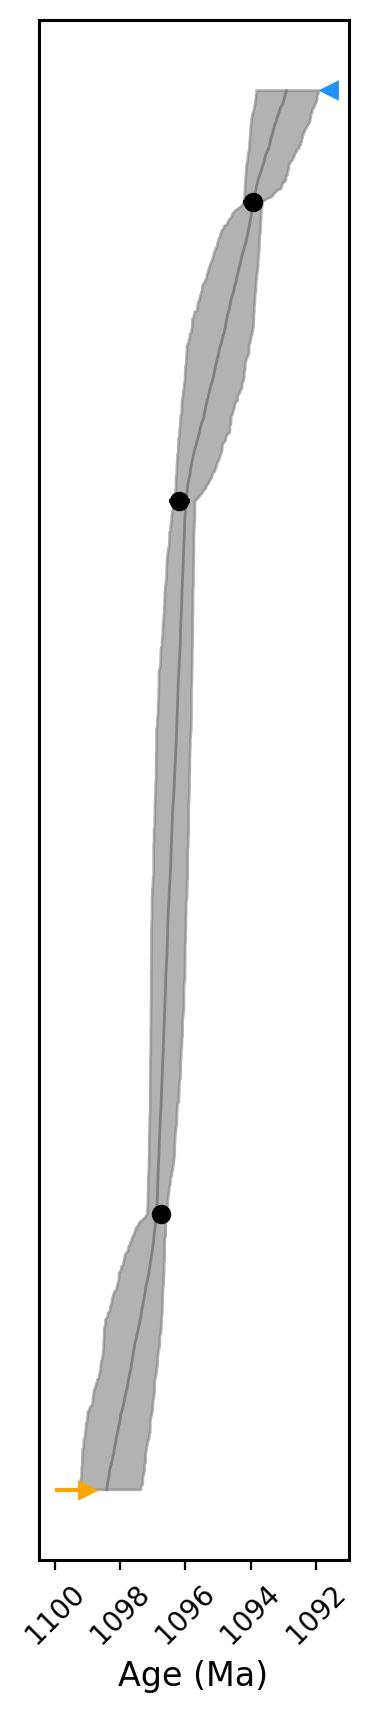

In [30]:
plot_age_model(
    NSVG_SW_Age,
    NSVG_SW_Age_sigma,
    NSVG_SW_Age_Sidedness,
    NSVG_SW_Height,
    NSVG_age_model
)

plt.xlim(1100.5, 1091)
# plt.ylim(0, 9000)
plt.xticks([1092, 1094, 1096, 1098, 1100], rotation=45, visible=True)
plt.yticks([], visible=0)

# ax.legend(loc='lower right', bbox_to_anchor=(1.1, 0.1), fontsize=12, frameon=True)
# specify frame line width
linewidth=1.1
plt.gca().spines['bottom'].set_linewidth(linewidth)
plt.gca().spines['left'].set_linewidth(linewidth)
plt.gca().spines['top'].set_linewidth(linewidth)
plt.gca().spines['right'].set_linewidth(linewidth)


plt.xlabel('Age (Ma)', fontsize=12)
plt.savefig('../figure/Keweenawan_NSVG_SW_with_age_model.pdf', bbox_inches='tight', transparent=False)
plt.show()

## draw example site stratigraphy with age model

In [31]:
# let's show the decoupled VGP age and stratigraphy
NSVG_SW_ultimate_ensemble = pseudo_ultimate_sites_ensemble_w_MAD[pseudo_ultimate_sites_ensemble_w_MAD['study'] == 'North Shore Volcanic Group (upper SW sequence)'].reset_index(drop=True)    
NSVG_SW_ultimate_ensemble.head()

,study,site,height,age,dec,inc,slat,slon,spolarity,plon,plat,run
0,North Shore Volcanic Group (upper SW sequence),ns050,3622.424125,1096.113426,291.598227,42.489131,46.88286,268.08416,n,180.814365,32.187691,0.0
1,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1096.113426,293.153549,43.872660,46.88497,268.08801,n,180.673316,33.949843,0.0
2,North Shore Volcanic Group (upper SW sequence),ns051,3809.431070,1096.113426,291.651939,42.165985,46.88497,268.08801,n,180.561835,32.062585,0.0
3,North Shore Volcanic Group (upper SW sequence),ns053,3430.871282,1096.113426,293.903445,43.007397,46.87654,268.06891,n,179.513648,34.022852,0.0
4,North Shore Volcanic Group (upper SW sequence),ns055,3051.536951,1096.426077,283.699341,36.527757,46.87575,268.04751,n,182.773221,23.909935,0.0


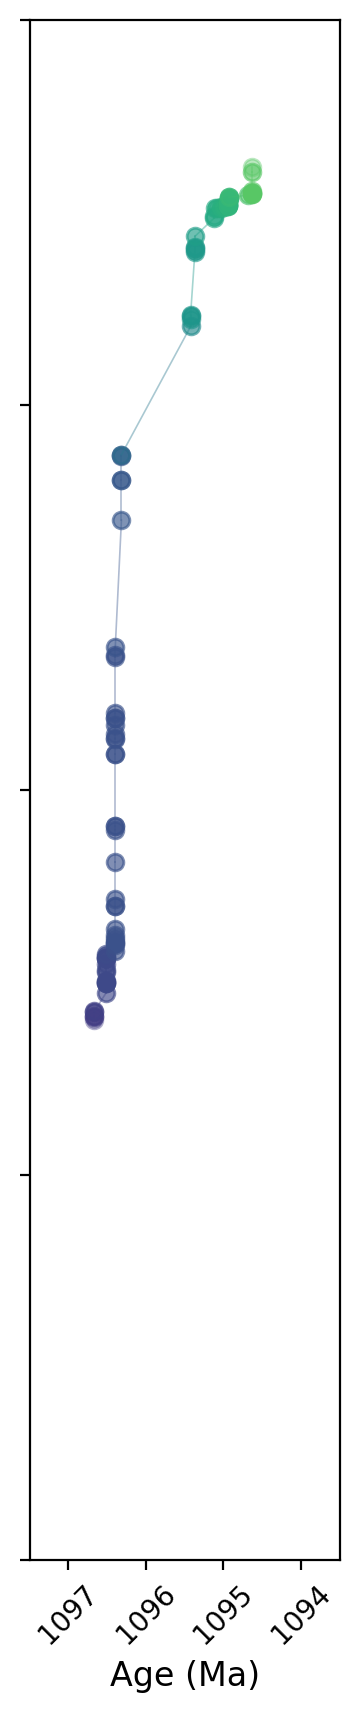

In [32]:
Normalize_NSVG_SW_ensemble = Normalize(vmin=NSVG_SW_ultimate_ensemble['age'].min(), vmax=NSVG_SW_ultimate_ensemble['age'].max())
cmap_NSVG_SW_ensemble = plt.cm.viridis_r

plt.figure(figsize=(2, 10))
for run in NSVG_SW_ultimate_ensemble['run'].unique()[8:9]:
    this_df = NSVG_SW_ultimate_ensemble[NSVG_SW_ultimate_ensemble['run'] == run]
    this_df.sort_values('height', inplace=True)
    for i in range(this_df.shape[0]-1):
        plt.plot([this_df['age'].iloc[i], this_df['age'].iloc[i+1]], [this_df['height'].iloc[i], this_df['height'].iloc[i+1]], 
                 color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(this_df['age'].iloc[i]/2 + this_df['age'].iloc[i+1]/2)), marker='o', lw=0.6, alpha=0.4)
# plt.scatter(NSVG_SW_ultimate_ensemble['age'][:87], NSVG_SW_ultimate_ensemble['height'][:87], 
#             color = cmap_NSVG_SW_ensemble(Normalize_NSVG_SW_ensemble(NSVG_SW_ultimate_ensemble['age'][:87])), alpha=0.6)
plt.xlim(1093.5, 1097.5)
# plt.ylim(0, 9000)
plt.xticks([1094, 1095, 1096, 1097], rotation=45, visible=True)
plt.yticks([0, 2000, 4000, 6000, 8000], [0, 2000, 4000, 6000, 8000], visible=0)
plt.gca().invert_xaxis()
# ax.tick_params(axis='both', which='both', length=5, labelsize=10)
plt.xlabel('Age (Ma)', fontsize=12)
# plt.ylabel('Height (m)', fontsize=12)
# plt.savefig('../figure/Keweenawan_NSVG_SW_with_age_model.pdf', bbox_inches='tight', transparent=False)
plt.show()